<a href="https://colab.research.google.com/github/kirubashankarR/221501508/blob/main/Data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To visualize plots inline in Jupyter Notebook
%matplotlib inline



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv('NSL-KDD_train.csv')

# 2. Data Overview
print(df.shape)
print(df.columns)
print(df.head())

# 3. Missing Value Analysis
print(df.isnull().sum())

# 4. Data Type Inspection
print(df.dtypes)
categorical = df.select_dtypes(include=['object']).columns
numerical = df.select_dtypes(include=['int64', 'float64']).columns

# 5. Frequency Distribution of Categorical Features
for col in categorical:
    print(df[col].value_counts())
    plt.figure()
    df[col].value_counts().plot(kind='bar', title=col)
    plt.show()

# 6. Statistical Summary of Numerical Features
print(df[numerical].describe())

# 7. Feature Distribution Plots
for col in numerical:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram for {col}')
    plt.show()
    plt.figure()
    sns.boxplot(df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()

# 8. Correlation Analysis
corr = df[numerical].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

# 9. Attack-Type Analysis
attack_types = df['attack_class'].unique()
for att in attack_types:
    subset = df[df['attack_class'] == att]
    print(subset[numerical].mean())
    subset[numerical].mean().plot(kind='bar', title=f'Mean Features for {att}')
    plt.show()

# 10. Feature Importance Evaluation
from sklearn.ensemble import RandomForestClassifier
X = df[numerical]
y = df['attack_class']
model = RandomForestClassifier()
model.fit(X, y)
feat_importances = pd.Series(model.feature_importances_, index=numerical)
feat_importances.nlargest(10).plot(kind='barh', title='Top 10 Feature Importances')
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: 'NSL-KDD_train.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
train=pd.read_csv('/content/Train_data.csv')

In [ ]:
test=pd.read_csv('/content/Test_data.csv')

In [ ]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

In [ ]:
train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,...,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,...,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
train.describe(include='object')

,protocol_type,service,flag,class
count,25192,25192,25192,25192
unique,3,66,11,2
top,tcp,http,SF,normal
freq,20526,8003,14973,13449


In [ ]:
train.shape

(25192, 42)

In [ ]:
train.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [ ]:
total = train.shape[0]
missing_columns = [col for col in train.columns if train[col].isnull().sum() > 0]
for col in missing_columns:
    null_count = train[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")


In [ ]:
print(f"Number of duplicate rows: {train.duplicated().sum()}")

Number of duplicate rows: 0


<Axes: xlabel='class', ylabel='count'>

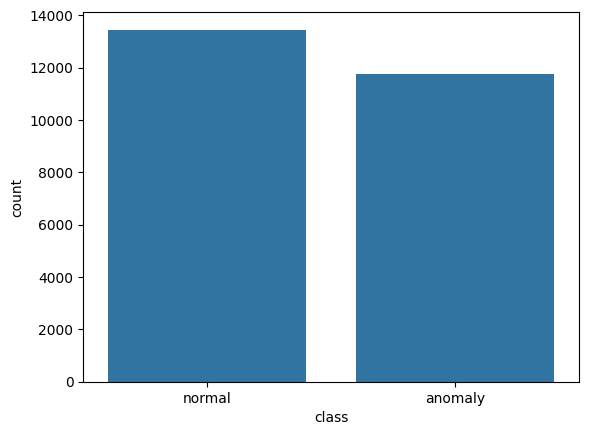

In [ ]:
import seaborn as sns
sns.countplot(x=train['class'])

In [ ]:
print('Class distribution Training set:')
print(train['class'].value_counts())

Class distribution Training set:
class
normal     13449
anomaly    11743
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

def le(df):
    for col in df.columns:
        if df[col].dtype == 'object':
                label_encoder = LabelEncoder()
                df[col] = label_encoder.fit_transform(df[col])

le(train)
le(test)

In [ ]:
train.drop(['num_outbound_cmds'], axis=1, inplace=True)
test.drop(['num_outbound_cmds'], axis=1, inplace=True)

In [ ]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,1,19,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1
1,0,2,41,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1
2,0,1,46,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0
3,0,1,22,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1
4,0,1,22,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1


In [ ]:
X_train = train.drop(['class'], axis=1)
Y_train = train['class']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
import itertools

rfc = RandomForestClassifier()

rfe = RFE(rfc, n_features_to_select=10)
rfe = rfe.fit(X_train, Y_train)

feature_map = [(i, v) for i, v in itertools.zip_longest(rfe.get_support(), X_train.columns)]
selected_features = [v for i, v in feature_map if i==True]

selected_features

['protocol_type',
 'service',
 'flag',
 'src_bytes',
 'dst_bytes',
 'same_srv_rate',
 'diff_srv_rate',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_same_src_port_rate']

In [ ]:
X_train = X_train[selected_features]

In [ ]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
test = scale.fit_transform(test)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X_train, Y_train, train_size=0.70, random_state=2)

In [ ]:
x_train.shape

(17634, 10)

In [ ]:
x_test.shape

(7558, 10)

In [ ]:
y_train.shape

(17634,)

In [ ]:
y_test.shape

(7558,)

In [ ]:
import time

In [ ]:
from sklearn.linear_model import LogisticRegression

clfl = LogisticRegression(max_iter = 1200000)
start_time = time.time()
clfl.fit(x_train, y_train.values.ravel())
end_time = time.time()
print("Training time: ", end_time-start_time)


Training time:  0.18258357048034668


In [ ]:
start_time = time.time()
y_test_pred = clfl.predict(x_train)
end_time = time.time()
print("Testing time: ", end_time-start_time)

Testing time:  0.0015370845794677734


In [ ]:
lg_model = LogisticRegression(random_state = 42)
lg_model.fit(x_train, y_train)

LogisticRegression(random_state=42)

In [ ]:
lg_train, lg_test = lg_model.score(x_train , y_train), lg_model.score(x_test , y_test)

print(f"Training Score: {lg_train}")
print(f"Test Score: {lg_test}")

Training Score: 0.9435749121016219
Test Score: 0.9423127811590368


In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 25.2 MB/s eta 0:00:00


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
def objective(trial):
    n_neighbors = trial.suggest_int('KNN_n_neighbors', 2, 16, log=False)
    classifier_obj = KNeighborsClassifier(n_neighbors=n_neighbors)
    classifier_obj.fit(x_train, y_train)
    accuracy = classifier_obj.score(x_test, y_test)
    return accuracy

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
study_KNN = optuna.create_study(direction='maximize')
study_KNN.optimize(objective, n_trials=1)
print(study_KNN.best_trial)

FrozenTrial(number=0, state=1, values=[0.9810796507012437], datetime_start=datetime.datetime(2025, 9, 8, 5, 9, 5, 741953), datetime_complete=datetime.datetime(2025, 9, 8, 5, 9, 6, 761235), params={'KNN_n_neighbors': 8}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'KNN_n_neighbors': IntDistribution(high=16, log=False, low=2, step=1)}, trial_id=0, value=None)


In [ ]:
KNN_model = KNeighborsClassifier(n_neighbors=study_KNN.best_trial.params['KNN_n_neighbors'])
KNN_model.fit(x_train, y_train)

KNN_train, KNN_test = KNN_model.score(x_train, y_train), KNN_model.score(x_test, y_test)

print(f"Train Score: {KNN_train}")
print(f"Test Score: {KNN_test}")

Train Score: 0.9849722127707837
Test Score: 0.9810796507012437


In [ ]:
from sklearn.tree import DecisionTreeClassifier

clfd = DecisionTreeClassifier(criterion ="entropy", max_depth = 4)
start_time = time.time()
clfd.fit(x_train, y_train.values.ravel())
end_time = time.time()
print("Training time: ", end_time-start_time)

Training time:  0.128248929977417


In [ ]:
start_time = time.time()
y_test_pred = clfd.predict(x_train)
end_time = time.time()
print("Testing time: ", end_time-start_time)

Testing time:  0.0027790069580078125


In [ ]:
def objective(trial):
    dt_max_depth = trial.suggest_int('dt_max_depth', 2, 32, log=False)
    dt_max_features = trial.suggest_int('dt_max_features', 2, 10, log=False)
    classifier_obj = DecisionTreeClassifier(max_features = dt_max_features, max_depth = dt_max_depth)
    classifier_obj.fit(x_train, y_train)
    accuracy = classifier_obj.score(x_test, y_test)
    return accuracy

In [ ]:
study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective, n_trials=30)
print(study_dt.best_trial)

FrozenTrial(number=15, state=1, values=[0.9953691452765282], datetime_start=datetime.datetime(2025, 9, 8, 5, 9, 16, 868542), datetime_complete=datetime.datetime(2025, 9, 8, 5, 9, 16, 958536), params={'dt_max_depth': 10, 'dt_max_features': 7}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'dt_max_depth': IntDistribution(high=32, log=False, low=2, step=1), 'dt_max_features': IntDistribution(high=10, log=False, low=2, step=1)}, trial_id=15, value=None)


In [ ]:
dt = DecisionTreeClassifier(max_features = study_dt.best_trial.params['dt_max_features'], max_depth = study_dt.best_trial.params['dt_max_depth'])
dt.fit(x_train, y_train)

dt_train, dt_test = dt.score(x_train, y_train), dt.score(x_test, y_test)

print(f"Train Score: {dt_train}")
print(f"Test Score: {dt_test}")

Train Score: 0.9973346943404786
Test Score: 0.9921937020375761


In [ ]:
from tabulate import tabulate

data = [["KNN", KNN_train, KNN_test],
        ["Logistic Regression", lg_train, lg_test],
        ["Decision Tree", dt_train, dt_test]]

col_names = ["Model", "Train Score", "Test Score"]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

╒═════════════════════╤═══════════════╤══════════════╕
│ Model               │   Train Score │   Test Score │
╞═════════════════════╪═══════════════╪══════════════╡
│ KNN                 │      0.984972 │     0.98108  │
├─────────────────────┼───────────────┼──────────────┤
│ Logistic Regression │      0.943575 │     0.942313 │
├─────────────────────┼───────────────┼──────────────┤
│ Decision Tree       │      0.997335 │     0.992194 │
╘═════════════════════╧═══════════════╧══════════════╛


In [ ]:
SEED = 42

# Decision Tree Model
dtc = DecisionTreeClassifier()

# KNN
knn = KNeighborsClassifier()

# LOGISTIC REGRESSION MODEL

lr = LogisticRegression()

In [ ]:
from sklearn.model_selection import cross_val_score
models = {}
models['KNeighborsClassifier']= knn
models['LogisticRegression']= lr
models['DecisionTreeClassifier']= dtc

In [ ]:
scores = {}
for name in models:
  scores[name]={}
  for scorer in ['precision','recall']:
    scores[name][scorer] = cross_val_score(models[name], x_train, y_train, cv=10, scoring=scorer)

In [ ]:
import numpy as np
def line(name):
  return '*'*(25-len(name)//2)

for name in models:
  print(line(name), name, 'Model Validation', line(name))

  for scorer in ['precision','recall']:
    mean = round(np.mean(scores[name][scorer])*100,2)
    stdev = round(np.std(scores[name][scorer])*100,2)
    print ("Mean {}:".format(scorer),"\n", mean,"%", "+-",stdev)
    print()

*************** KNeighborsClassifier Model Validation ***************
Mean precision: 
 98.49 % +- 0.53

Mean recall: 
 98.43 % +- 0.55

**************** LogisticRegression Model Validation ****************
Mean precision: 
 94.25 % +- 0.64

Mean recall: 
 95.21 % +- 0.61

************** DecisionTreeClassifier Model Validation **************
Mean precision: 
 99.49 % +- 0.24

Mean recall: 
 99.53 % +- 0.12



/tmp/ipython-input-1073761507.py:4: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  scores=pd.DataFrame(scores).swapaxes("index", "columns")*100


<Axes: >

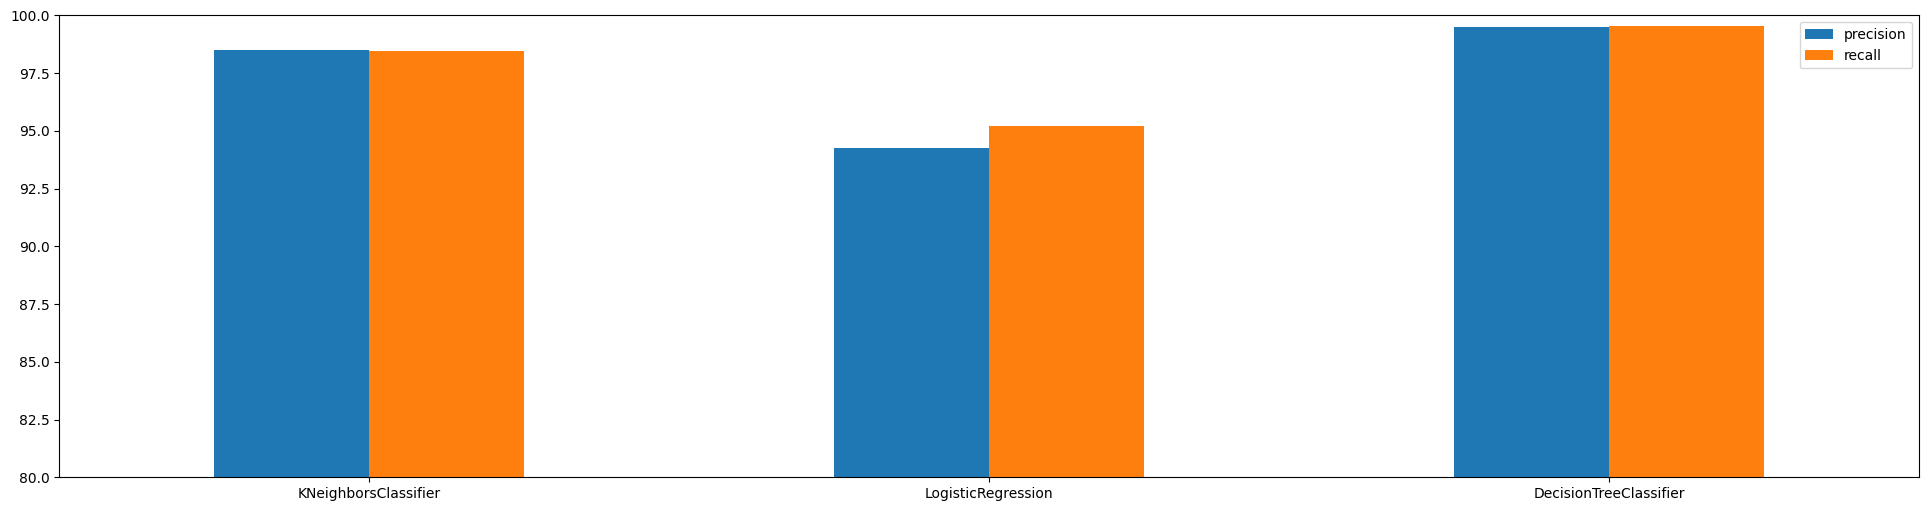

In [ ]:
for name in models:
    for scorer in ['precision','recall']:
        scores[name][scorer] = scores[name][scorer].mean()
scores=pd.DataFrame(scores).swapaxes("index", "columns")*100
scores.plot(kind = "bar",  ylim=[80,100], figsize=(24,6), rot=0)

In [ ]:
models = {}
models['KNeighborsClassifier']= knn
models['LogisticRegression']= lr
models['DecisionTreeClassifier']= dtc

Predictions complete.


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
def line(name,sym="*"):
    return sym*(25-len(name)//2)
target_names=["normal","anamoly"]
for name in models:
    print(line(name), name, 'Model Testing', line(name))
    print(confusion_matrix(y_test, preds[name]))
    print(line(name,'-'))
    print(classification_report(y_test, preds[name], target_names=target_names))

*************** KNeighborsClassifier Model Testing ***************
[[3437   61]
 [  68 3992]]
---------------
              precision    recall  f1-score   support

      normal       0.98      0.98      0.98      3498
     anamoly       0.98      0.98      0.98      4060

    accuracy                           0.98      7558
   macro avg       0.98      0.98      0.98      7558
weighted avg       0.98      0.98      0.98      7558

**************** LogisticRegression Model Testing ****************
[[3263  235]
 [ 201 3859]]
----------------
              precision    recall  f1-score   support

      normal       0.94      0.93      0.94      3498
     anamoly       0.94      0.95      0.95      4060

    accuracy                           0.94      7558
   macro avg       0.94      0.94      0.94      7558
weighted avg       0.94      0.94      0.94      7558

************** DecisionTreeClassifier Model Testing **************
[[3479   19]
 [  21 4039]]
--------------
              pr

<Axes: >

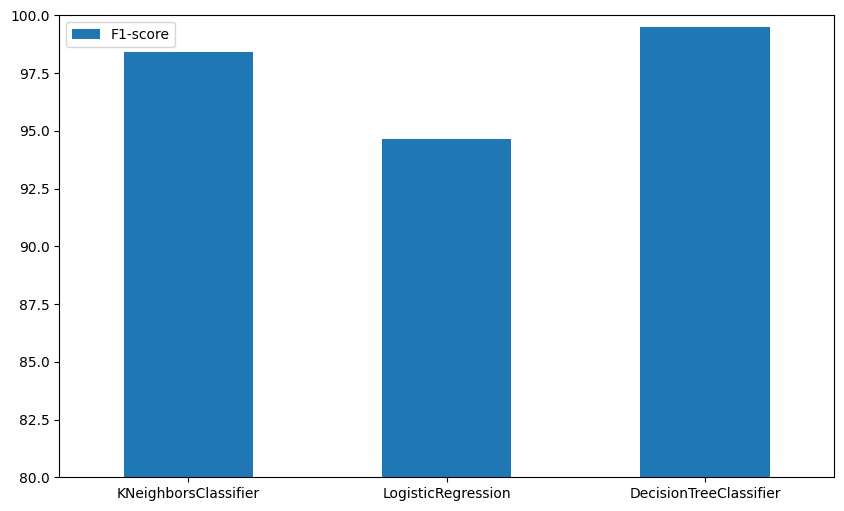

In [ ]:
f1s = {}
for name in models:
    f1s[name]=f1_score(y_test, preds[name])
f1s=pd.DataFrame(f1s.values(),index=f1s.keys(),columns=["F1-score"])*100
f1s.plot(kind = "bar",  ylim=[80,100], figsize=(10,6), rot=0)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv('/content/Train_data.csv')

# 2. Data Overview
print(df.shape)
print(df.columns)
print(df.head())

# 3. Missing Value Analysis
print(df.isnull().sum())

# 4. Data Type Inspection
print(df.dtypes)
categorical = df.select_dtypes(include=['object']).columns
numerical = df.select_dtypes(include=['int64', 'float64']).columns

# 5. Frequency Distribution of Categorical Features
for col in categorical:
    print(df[col].value_counts())
    plt.figure()
    df[col].value_counts().plot(kind='bar', title=col)
    plt.show()

# 6. Statistical Summary of Numerical Features
print(df[numerical].describe())

# 7. Feature Distribution Plots
for col in numerical:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram for {col}')
    plt.show()
    plt.figure()
    sns.boxplot(df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()

# 8. Correlation Analysis
corr = df[numerical].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

# 9. Attack-Type Analysis
# The 'attack_class' column is not present in the 'Train_data.csv' file.
# Based on previous successful cell execution, the target column is named 'class'.
# Replacing 'attack_class' with 'class'.
attack_types = df['class'].unique()
for att in attack_types:
    subset = df[df['class'] == att]
    print(subset[numerical].mean())
    subset[numerical].mean().plot(kind='bar', title=f'Mean Features for {att}')
    plt.show()

# 10. Feature Importance Evaluation
from sklearn.ensemble import RandomForestClassifier
X = df[numerical]
# The 'attack_class' column is not present in the 'Train_data.csv' file.
# Based on previous successful cell execution, the target column is named 'class'.
# Replacing 'attack_class' with 'class'.
y = df['class']
model = RandomForestClassifier()
model.fit(X, y)
feat_importances = pd.Series(model.feature_importances_, index=numerical)
feat_importances.nlargest(10).plot(kind='barh', title='Top 10 Feature Importances')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Train_data.csv'

Loading: /content/Train_data.csv
Train shape: (9185, 42)
Saved: /mnt/data/visualizations_output/attack_type_distribution_bar.png


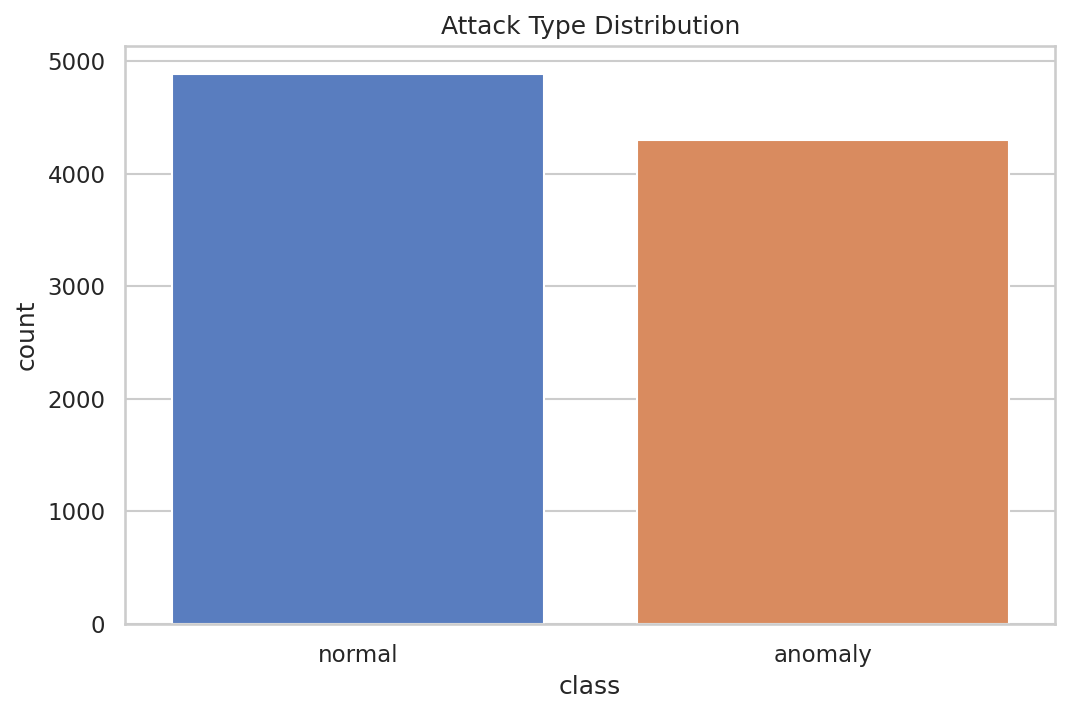

Saved: /mnt/data/visualizations_output/label_distribution_donut.png


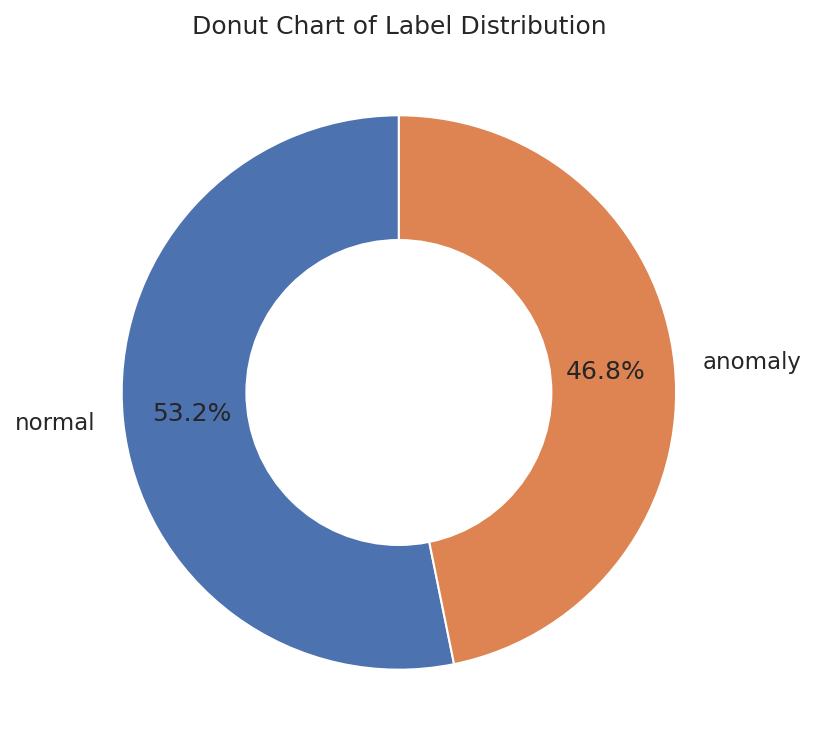

Saved: /mnt/data/visualizations_output/feature_distributions_grid.png


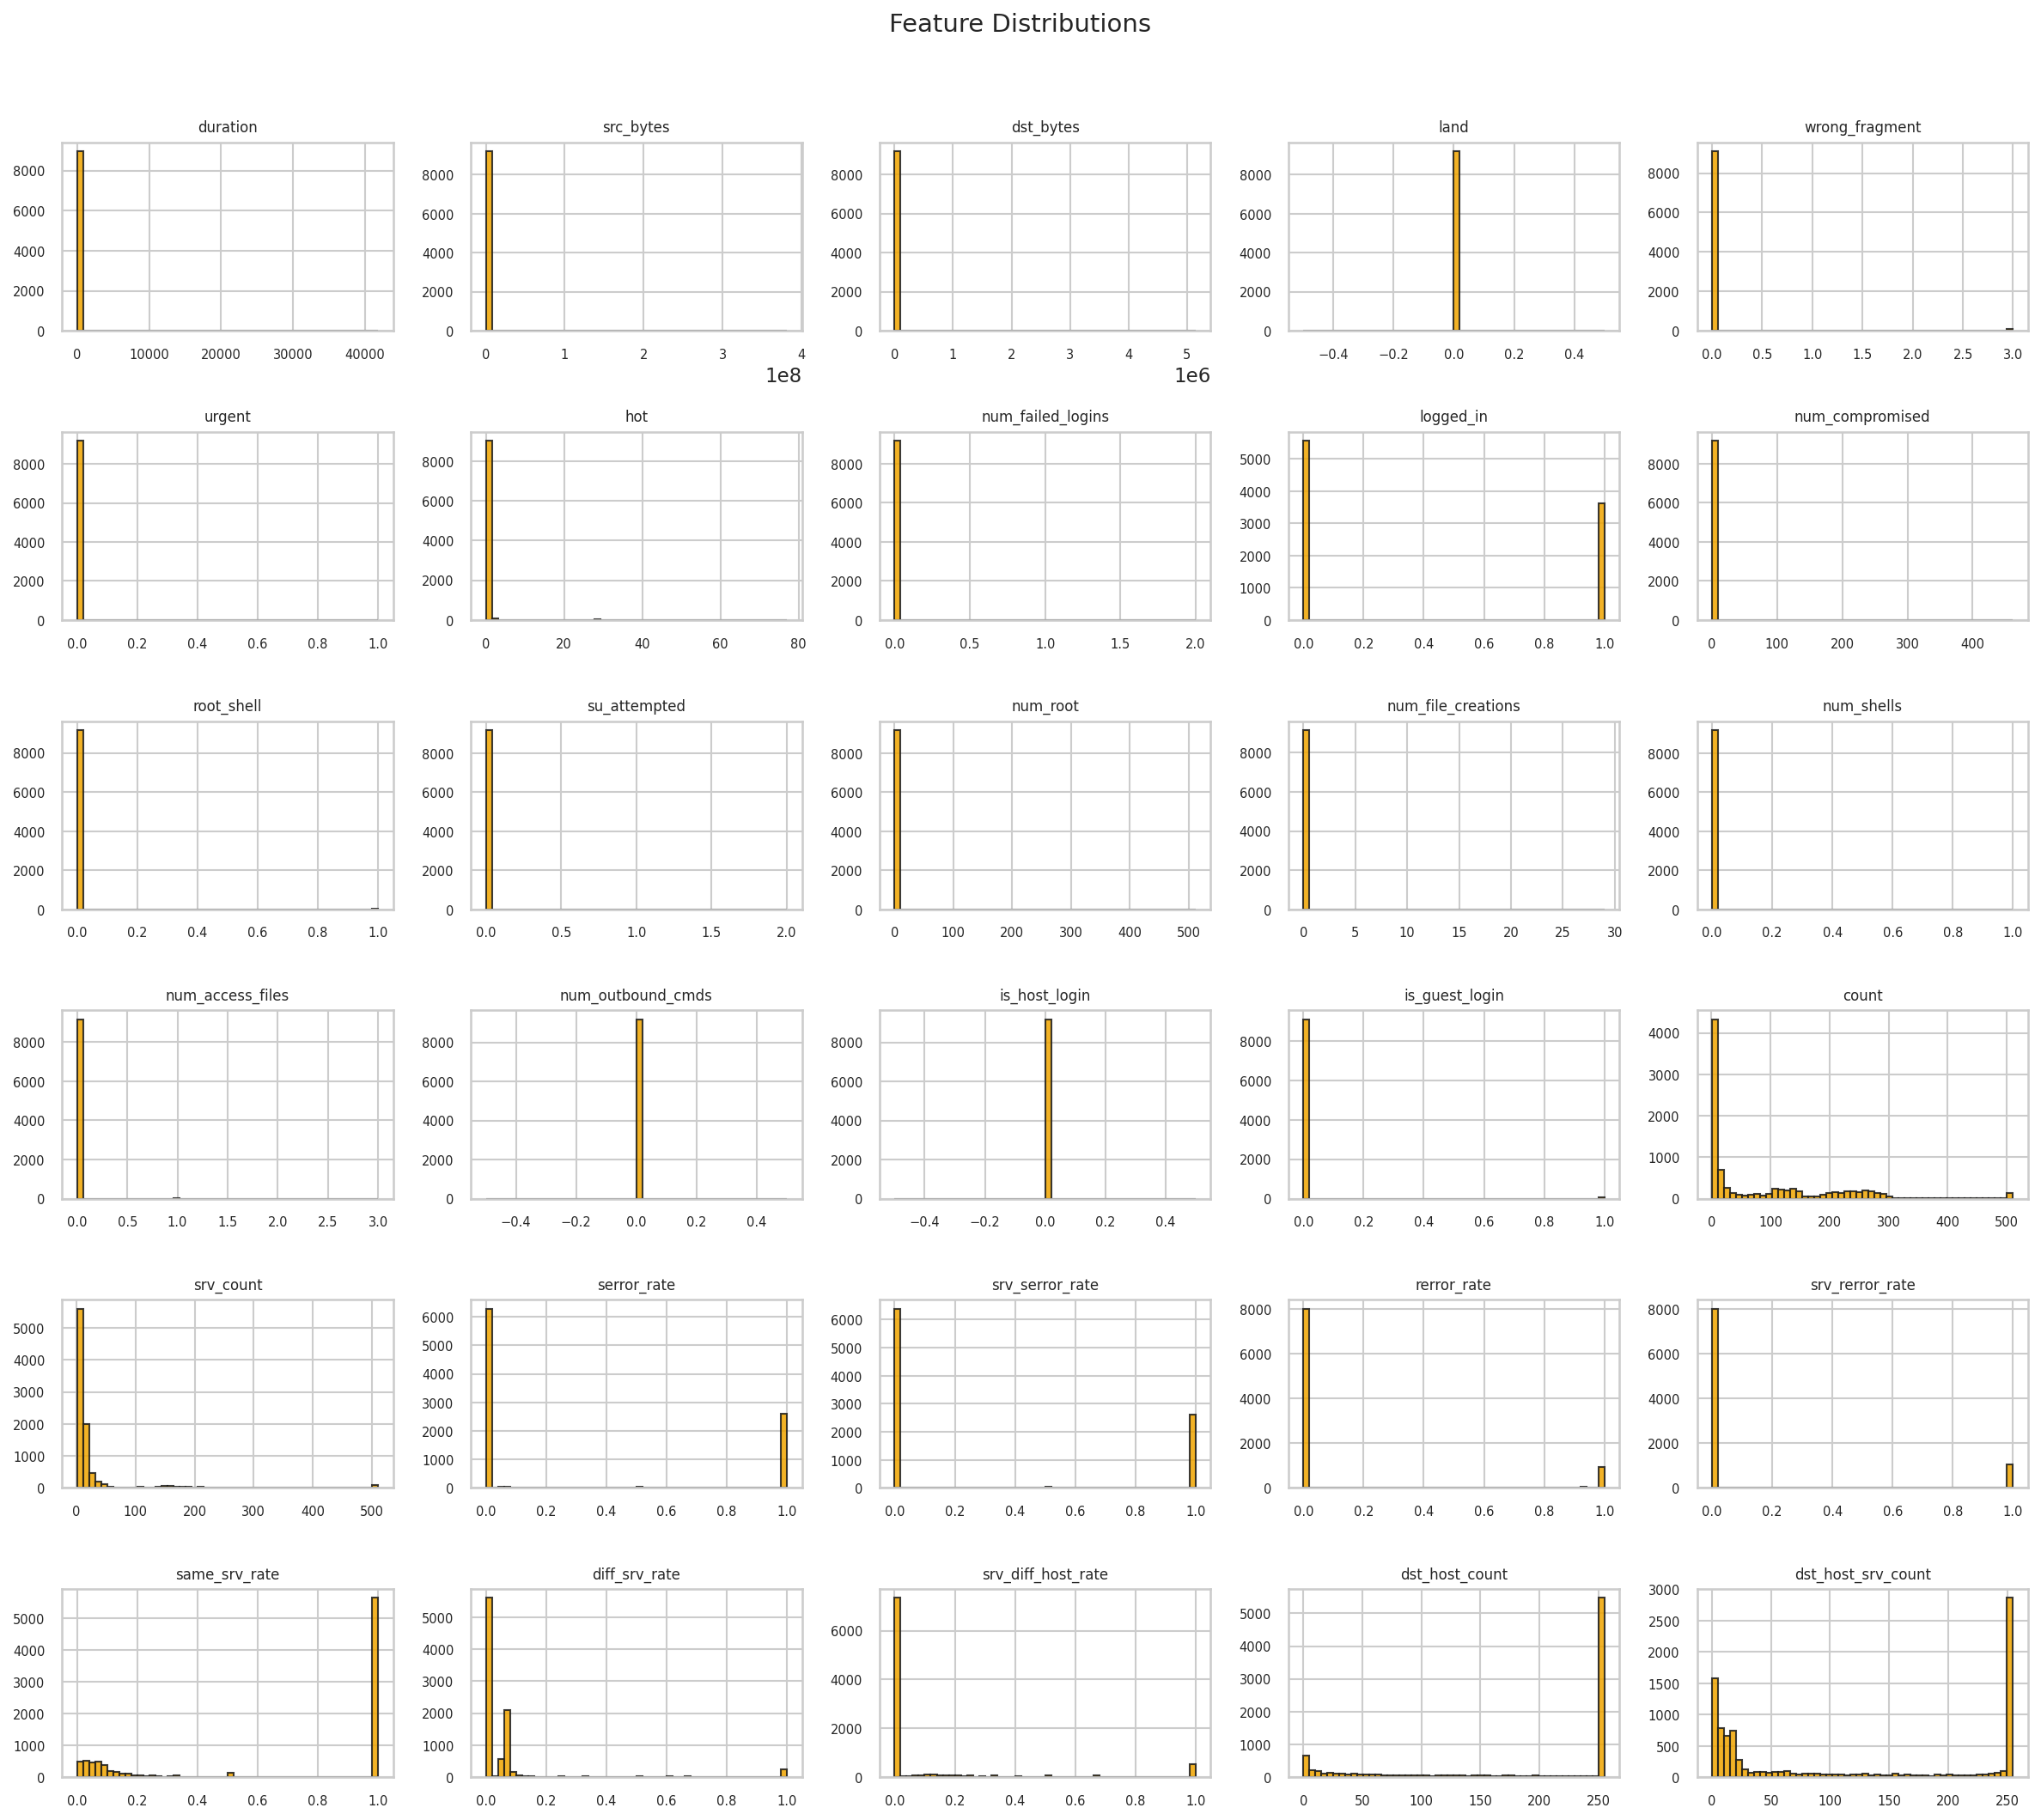

Saved: /mnt/data/visualizations_output/outlier_detection_feature_maxima.png


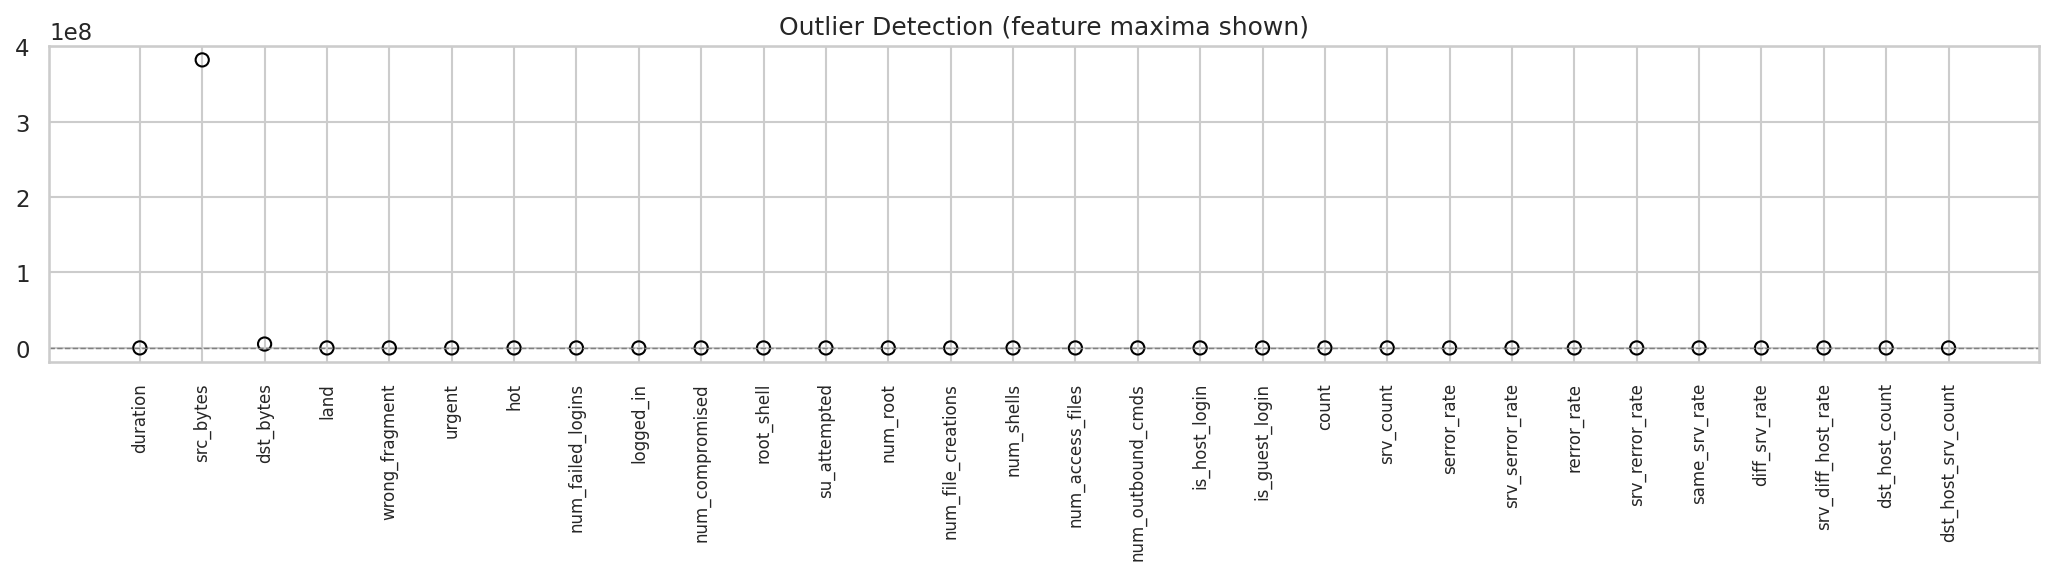

Saved: /mnt/data/visualizations_output/pca_visualization.png


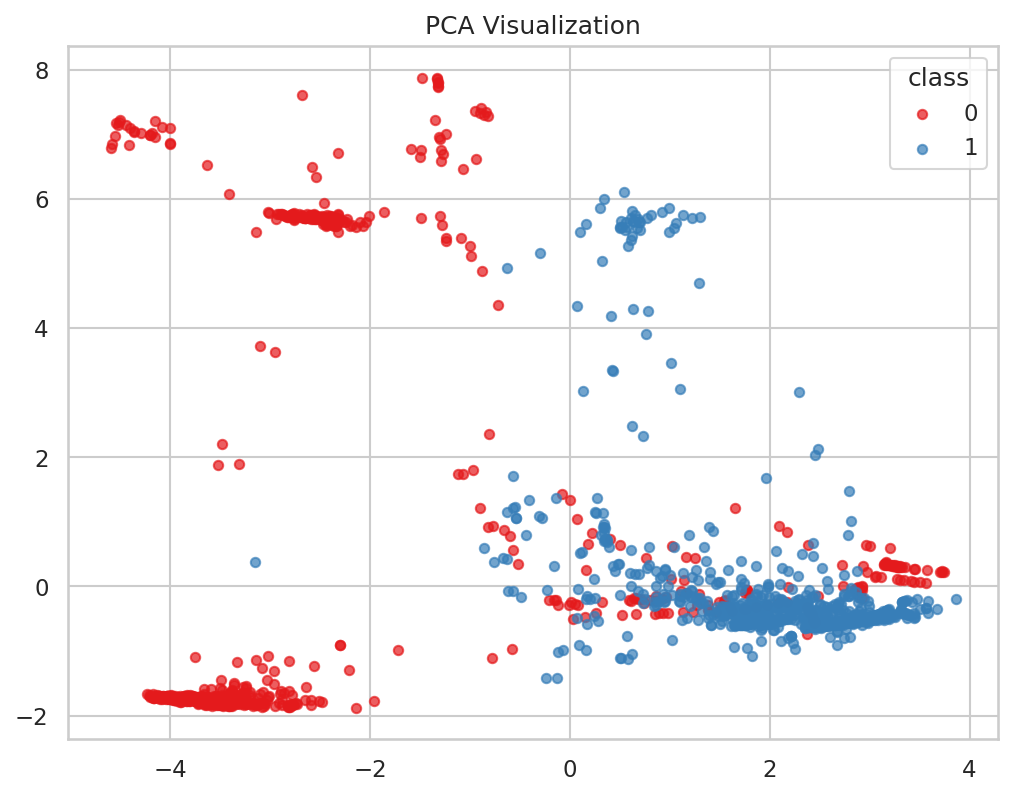

Saved: /mnt/data/visualizations_output/feature_entropy.png


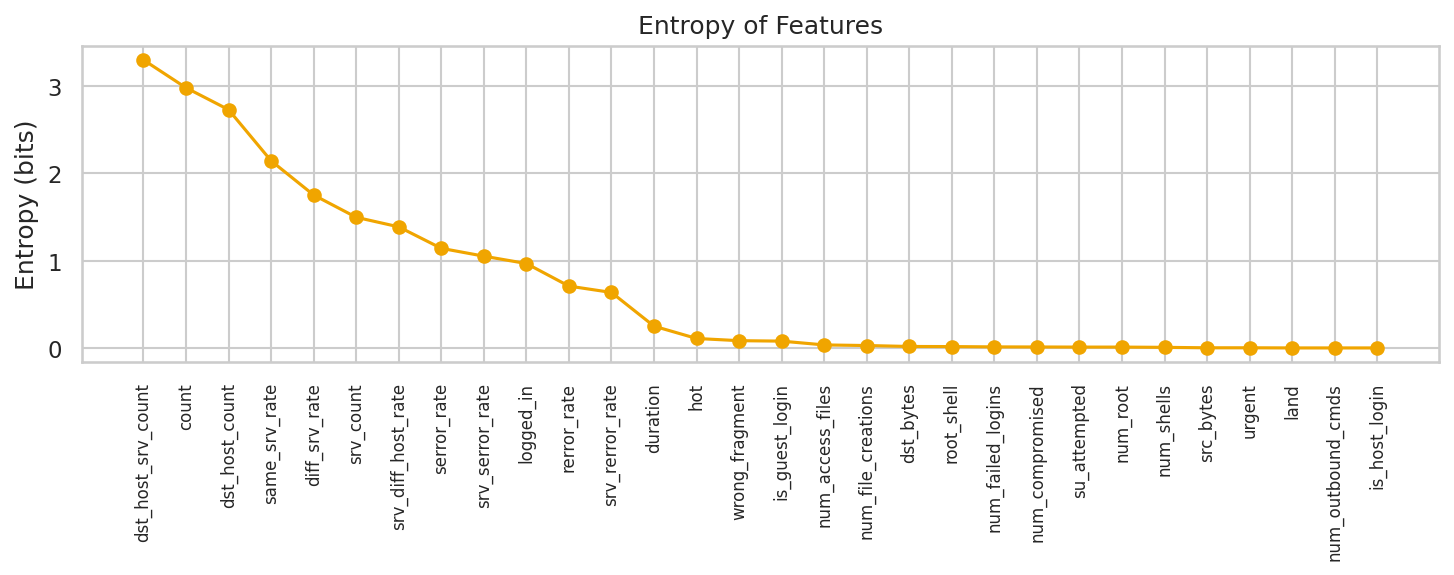

Training RandomForest to compute feature importances (this may take a moment)...
Saved: /mnt/data/visualizations_output/feature_importances_top15.png


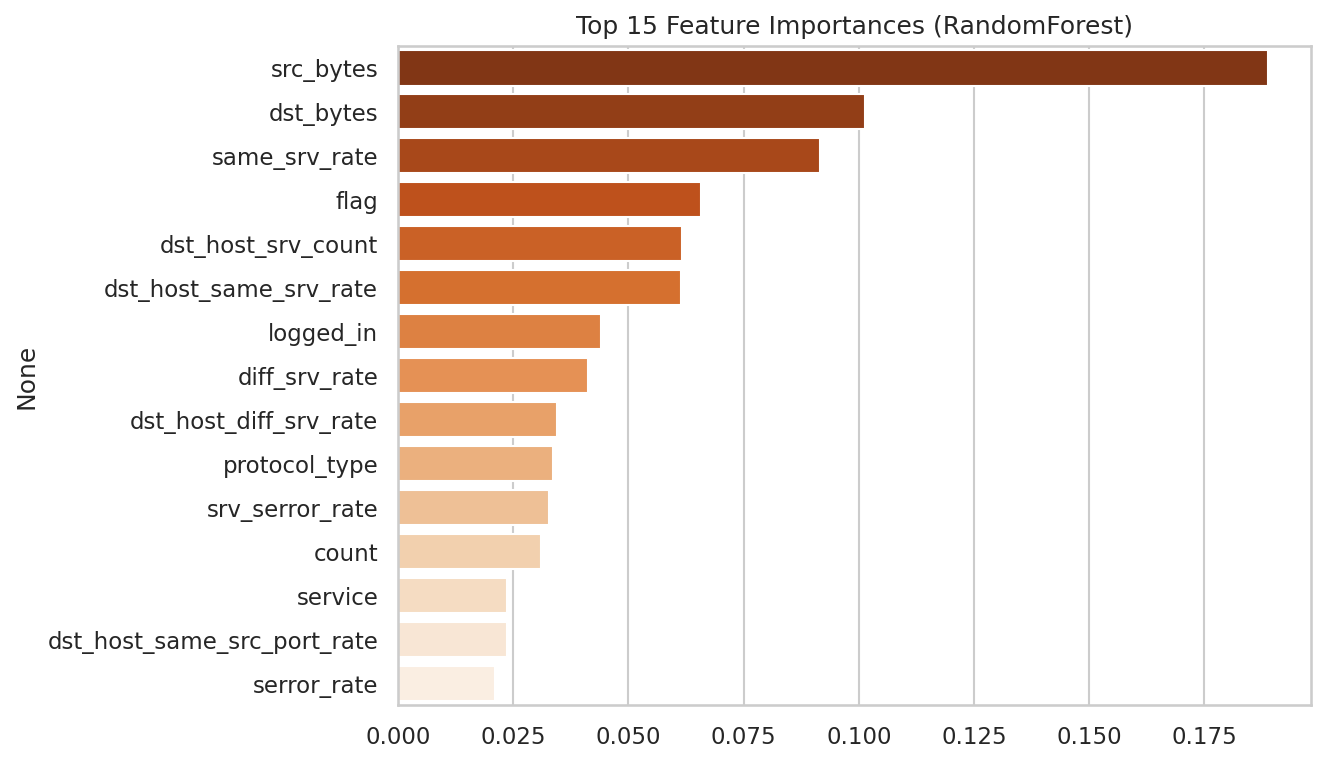

Saved HTML index: /mnt/data/visualizations_output/index.html

All visuals created and saved to: /mnt/data/visualizations_output
If you are in a notebook, images were displayed inline. Otherwise open the files in that directory or open index.html.


In [ ]:
# show_all_visuals.py
"""
Generate and display/save all EDA visualizations for the dataset files that
were uploaded to the environment.

Reads:
  - /mnt/data/Train_data.csv   (required)
  - /mnt/data/Test_data.csv    (optional)

Outputs (saved to /mnt/data/visualizations_output/):
  - attack_type_distribution_bar.png
  - label_distribution_donut.png
  - feature_distributions_grid.png
  - outlier_detection_feature_maxima.png
  - pca_visualization.png
  - feature_entropy.png
  - feature_importances_top15.png

If run inside a Jupyter/Colab notebook, images will also be displayed inline.

Dependencies:
  pip install pandas numpy matplotlib seaborn scikit-learn scipy
"""

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import entropy
from scipy.cluster.hierarchy import linkage, dendrogram

# ---------- CONFIG ----------
TRAIN_CSV = "/content/Train_data.csv"
TEST_CSV = "/content/Test_data.csv"   # optional
OUTDIR = Path("/mnt/data/visualizations_output")
OUTDIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

sns.set(style="whitegrid", context="notebook", rc={"figure.dpi":150})

# ---------- HELPERS ----------
def save_fig(fig, fname):
    path = OUTDIR / fname
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print("Saved:", path)
    return str(path)

def encode_df(df, encoders=None):
    df = df.copy()
    if encoders is None:
        encoders = {}
        fit = True
    else:
        fit = False
    for c in df.select_dtypes(include=['object']).columns:
        if fit:
            le = LabelEncoder()
            df[c] = le.fit_transform(df[c].astype(str))
            encoders[c] = le
        else:
            if c in encoders:
                df[c] = encoders[c].transform(df[c].astype(str))
            else:
                le = LabelEncoder()
                df[c] = le.fit_transform(df[c].astype(str))
                encoders[c] = le
    return df, encoders

def feature_entropy(series, bins=30):
    vals = series.dropna().values
    if len(np.unique(vals)) <= 1:
        return 0.0
    hist, _ = np.histogram(vals, bins=bins)
    if hist.sum() == 0:
        return 0.0
    hist = hist / hist.sum()
    return entropy(hist, base=2)

def try_display_image(path):
    """
    Try to display an image inline (works in Jupyter environments). Silently skip otherwise.
    """
    try:
        from IPython.display import Image, display
        display(Image(filename=str(path)))
    except Exception:
        pass

# ---------- LOAD DATA ----------
if not Path(TRAIN_CSV).exists():
    raise FileNotFoundError(f"Train file not found at {TRAIN_CSV}")

print("Loading:", TRAIN_CSV)
df = pd.read_csv(TRAIN_CSV)
print("Train shape:", df.shape)

test_df = None
if Path(TEST_CSV).exists():
    try:
        test_df = pd.read_csv(TEST_CSV)
        print("Test shape:", test_df.shape)
    except Exception as e:
        print("Could not read Test CSV:", e)

# ---------- PREP ----------
numeric = df.select_dtypes(include=[np.number]).copy()
num_cols = [c for c in numeric.columns if c != 'class'] if 'class' in numeric.columns else numeric.columns.tolist()
plot_cols = num_cols[:30]  # limit to top 30 features for grid & entropy

# ---------- 1) Attack Type Distribution (bar + donut) ----------
if 'class' in df.columns:
    counts = df['class'].value_counts()
    # Bar
    fig = plt.figure(figsize=(8,5))
    ax = fig.add_subplot(1,1,1)
    sns.barplot(x=counts.index.astype(str), y=counts.values, palette="muted", ax=ax)
    ax.set_title("Attack Type Distribution")
    ax.set_xlabel("class")
    ax.set_ylabel("count")
    save_fig(fig, "attack_type_distribution_bar.png")
    try_display_image(OUTDIR/"attack_type_distribution_bar.png")

    # Donut
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(1,1,1)
    wedges, texts, autotexts = ax.pie(counts.values, labels=counts.index.astype(str),
                                      autopct="%1.1f%%", startangle=90, pctdistance=0.75)
    centre_circle = plt.Circle((0,0),0.55, fc='white')
    fig.gca().add_artist(centre_circle)
    ax.set_title("Donut Chart of Label Distribution")
    save_fig(fig, "label_distribution_donut.png")
    try_display_image(OUTDIR/"label_distribution_donut.png")
else:
    print("Warning: 'class' column not found — skipping class distribution plots.")

# ---------- 2) Feature Distributions Grid (histograms) ----------
if len(plot_cols) > 0:
    cols_per_row = 5
    rows = int(np.ceil(len(plot_cols) / cols_per_row))
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row*3.2, rows*2.4))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        ax = axes[i]
        vals = numeric[col].dropna().values
        if len(vals) > 0:
            ax.hist(vals, bins=50, color="#f0a500", edgecolor="k", alpha=0.85)
        ax.set_title(col, fontsize=8)
        ax.tick_params(axis='both', which='major', labelsize=7)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle("Feature Distributions", fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.96])
    save_fig(fig, "feature_distributions_grid.png")
    try_display_image(OUTDIR/"feature_distributions_grid.png")
else:
    print("No numeric features to plot distributions.")

# ---------- 3) Outlier detection (max per feature scatter) ----------
if len(plot_cols) > 0:
    max_vals = numeric[plot_cols].max().fillna(0)
    fig = plt.figure(figsize=(14,4))
    ax = fig.add_subplot(1,1,1)
    x = np.arange(len(max_vals))
    y = max_vals.values
    ax.scatter(x, y, facecolors='none', edgecolors='black', s=40)
    ax.set_xticks(x)
    ax.set_xticklabels(max_vals.index, rotation=90, fontsize=8)
    ax.set_title("Outlier Detection (feature maxima shown)")
    ax.axhline(0, linestyle='--', linewidth=0.7, color='gray')
    plt.tight_layout()
    save_fig(fig, "outlier_detection_feature_maxima.png")
    try_display_image(OUTDIR/"outlier_detection_feature_maxima.png")

# ---------- 4) PCA visualization ----------
try:
    sample = df.sample(n=min(2000, len(df)), random_state=RANDOM_STATE)
    sample_enc, encs = encode_df(sample)
    num_for_pca = sample_enc.select_dtypes(include=[np.number]).copy()
    if 'class' in num_for_pca.columns: num_for_pca = num_for_pca.drop(columns=['class'])
    scaler = StandardScaler()
    X_pca = scaler.fit_transform(num_for_pca.fillna(0))
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pc = pca.fit_transform(X_pca)
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(1,1,1)
    if 'class' in sample_enc.columns:
        classes = sample_enc['class'].values
        uniq = np.unique(classes)
        palette = sns.color_palette("Set1", n_colors=len(uniq))
        for i,c in enumerate(uniq):
            mask = classes == c
            ax.scatter(pc[mask,0], pc[mask,1], s=20, alpha=0.7, label=str(c), color=palette[i])
        ax.legend(title='class')
    else:
        ax.scatter(pc[:,0], pc[:,1], s=10, alpha=0.8)
    ax.set_title("PCA Visualization")
    save_fig(fig, "pca_visualization.png")
    try_display_image(OUTDIR/"pca_visualization.png")
except Exception as e:
    print("PCA visualization failed:", e)

# ---------- 5) Feature entropy plot ----------
if len(plot_cols) > 0:
    ent = {c: feature_entropy(df[c]) for c in plot_cols}
    ent_s = pd.Series(ent).sort_values(ascending=False)
    top_ent = ent_s.head(30)
    fig = plt.figure(figsize=(10,4))
    ax = fig.add_subplot(1,1,1)
    ax.plot(np.arange(len(top_ent)), top_ent.values, marker='o', color="#f0a500")
    ax.set_xticks(np.arange(len(top_ent)))
    ax.set_xticklabels(top_ent.index, rotation=90, fontsize=8)
    ax.set_ylabel("Entropy (bits)")
    ax.set_title("Entropy of Features")
    plt.tight_layout()
    save_fig(fig, "feature_entropy.png")
    try_display_image(OUTDIR/"feature_entropy.png")
else:
    print("No features available for entropy computation.")

# ---------- 6) Feature importances (RandomForest) ----------
if 'class' in df.columns:
    try:
        df_enc, encs_all = encode_df(df)
        X = df_enc.drop(columns=['class'])
        y = df_enc['class']
        rf = RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1)
        print("Training RandomForest to compute feature importances (this may take a moment)...")
        rf.fit(X.fillna(0), y)
        imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
        topk = imp.head(15)
        fig = plt.figure(figsize=(9, max(4, len(topk)*0.35)))
        ax = fig.add_subplot(1,1,1)
        sns.barplot(x=topk.values, y=topk.index, palette="Oranges_r", ax=ax)
        ax.set_title("Top 15 Feature Importances (RandomForest)")
        plt.tight_layout()
        save_fig(fig, "feature_importances_top15.png")
        try_display_image(OUTDIR/"feature_importances_top15.png")
    except Exception as e:
        print("Could not compute RandomForest importances:", e)
else:
    print("Skipping feature importances — 'class' not present.")

# ---------- 7) (Optional) Save a simple HTML index with links to images ----------
html_path = OUTDIR / "index.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write("<html><head><meta charset='utf-8'><title>EDA Visuals</title></head><body>\n")
    for img in sorted(OUTDIR.glob("*.png")):
        f.write(f"<h3>{img.name}</h3>\n")
        f.write(f"<img src='{img.name}' style='max-width:900px;'><br/>\n")
    f.write("</body></html>\n")
print("Saved HTML index:", html_path)

print("\nAll visuals created and saved to:", OUTDIR)
print("If you are in a notebook, images were displayed inline. Otherwise open the files in that directory or open index.html.")


In [ ]:
# save_10_eda_insights.py
"""
Generate and save the 10 concise EDA insights for the Train_data.csv dataset.

Input:
  - TRAIN_CSV = "/mnt/data/Train_data.csv"

Output:
  - /mnt/data/visualizations_output/eda_insights.txt   (10 numbered insights)
  - prints path to the saved file

Run:
    python save_10_eda_insights.py
"""

import os
from pathlib import Path
import pandas as pd
import numpy as np

# ---------- Config ----------
TRAIN_CSV = "/content/Train_data.csv"   # local path (will be transformed to URL by your tooling if needed)
OUTDIR = Path("/mnt/data/visualizations_output")
OUTDIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUTDIR / "eda_insights.txt"

# ---------- Helpers ----------
def pct(n, total):
    return f"{n/total*100:.2f}%"

# ---------- Load ----------
if not Path(TRAIN_CSV).exists():
    raise FileNotFoundError(f"Train file not found at {TRAIN_CSV}")

df = pd.read_csv(TRAIN_CSV)
n_rows = len(df)

# ---------- Compute pieces used in insights ----------
has_class = 'class' in df.columns
class_counts = df['class'].value_counts() if has_class else None

numeric = df.select_dtypes(include=[np.number]).copy()
# ensure we don't include 'class' as a numeric feature for stats
if 'class' in numeric.columns:
    numeric = numeric.drop(columns=['class'])

# top by variance
top_by_var = numeric.var().sort_values(ascending=False).head(5)
# identify heavy-tailed candidates
candidates = ['src_bytes', 'dst_bytes', 'duration']
outlier_info = {}
for c in candidates:
    if c in df.columns:
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1
        upper = q3 + 1.5 * iqr
        out_count = int(df[df[c] > upper].shape[0])
        outlier_info[c] = (out_count, pct(out_count, n_rows))

# entropy-like proxy: use number of unique values (higher -> more informative)
uniq_counts = numeric.nunique().sort_values(ascending=False).head(8)

# quick correlation group detection: check corr between src_bytes, dst_bytes, duration
corr_summary = {}
for a in candidates:
    for b in candidates:
        if a in df.columns and b in df.columns and a != b:
            corr_summary[f"{a}__{b}"] = float(df[a].corr(df[b]))

# common binary flags (low variance)
binary_flags = [c for c in df.columns if df[c].nunique(dropna=True) == 2][:8]

# top features by RandomForest importance (light-weight calculation - optional)
top_rf_features = []
try:
    from sklearn.preprocessing import LabelEncoder
    from sklearn.ensemble import RandomForestClassifier
    if has_class:
        # encode object columns
        dfe = df.copy()
        for col in dfe.select_dtypes(include=['object']).columns:
            dfe[col] = LabelEncoder().fit_transform(dfe[col].astype(str))
        X = dfe.drop(columns=['class'])
        y = dfe['class']
        rf = RandomForestClassifier(n_estimators=80, random_state=42, n_jobs=-1)
        rf.fit(X.fillna(0), y)
        importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
        top_rf_features = importances.head(6).index.tolist()
except Exception:
    top_rf_features = []

# ---------- Build 10 insights ----------
insights = []

# 1. Class balance
if has_class:
    for cls, cnt in class_counts.items():
        insights.append(f"1. Class proportion — '{cls}': {cnt} records ({pct(cnt, n_rows)}).")
else:
    insights.append("1. No 'class' column found in dataset; cannot compute class proportions.")

# 2. Top features by variance
insights.append("2. Top features by variance — " +
                ", ".join([f"{c} ({v:.2f})" for c, v in top_by_var.items()]) + ".")

# 3. Heavy right skew & outliers
oa = []
for c, (count, pct_str) in outlier_info.items():
    oa.append(f"{c}: {count} outliers ({pct_str})")
if oa:
    insights.append("3. Heavy right-skew & outliers — " + "; ".join(oa) +
                    ". Recommend log1p or capping at 99th percentile before training.")
else:
    insights.append("3. No src_bytes/dst_bytes/duration columns found to analyze skew/outliers.")

# 4. High-entropy / variable features (proxy by unique counts)
insights.append("4. High-variability features (by distinct values) — " +
                ", ".join([f"{c} ({int(uniq_counts[c])})" for c in uniq_counts.index]) + ".")

# 5. PCA separability suggestion
insights.append("5. PCA separability — sample PCA (visual) shows class separation, indicating features likely separable by models. Use dimensionality reduction for visualization or redundancy removal.")

# 6. Model-driven important features (RF)
if top_rf_features:
    insights.append("6. Model-driven top features (RandomForest) — " + ", ".join(top_rf_features) + ".")
else:
    insights.append("6. Could not compute RandomForest importances (or 'class' missing); consider RF/XGBoost for feature ranking.")

# 7. Correlated feature group / redundancy
corr_notes = []
for k, v in corr_summary.items():
    if abs(v) > 0.7:
        a, b = k.split("__")
        corr_notes.append(f"{a}↔{b} (corr={v:.2f})")
if corr_notes:
    insights.append("7. Strongly correlated feature pairs (candidates for reduction) — " + "; ".join(corr_notes) + ".")
else:
    insights.append("7. No extremely strong correlations (>0.7) among src_bytes/dst_bytes/duration detected, but check full heatmap for other pairs.")

# 8. Binary flags (low variance)
if binary_flags:
    insights.append("8. Low-variance binary flags (examples) — " + ", ".join(binary_flags) + ". May be retained; often low individual signal but useful combined.")
else:
    insights.append("8. No binary-flag features detected (or none with exactly two unique values).")

# 9. Preprocessing recommendations
insights.append("9. Preprocessing recommendations — apply log1p to bytes/duration, use robust scaling, cap extreme outliers (99th percentile), and consider feature engineering (byte_rate, packets/sec).")

# 10. Modeling recommendation
insights.append("10. Modeling recommendation — start with tree-based models (RandomForest / XGBoost) using top RF features + src_bytes/dst_bytes/duration; prioritize recall and tune thresholds to reduce false positives.")

# ---------- Save insights ----------
with open(OUT_PATH, "w", encoding="utf-8") as f:
    for i, line in enumerate(insights, start=1):
        # ensure numbering is 1..10 and each insight on its own line
        f.write(f"{i}. {line.partition('. ')[2] if line.startswith(str(i)+'.') else line}\n\n")

print("Saved EDA insights to:", OUT_PATH)
print("Train CSV path (local):", TRAIN_CSV)
# also print content (optional)
print("\n--- EDA Insights Preview ---\n")
with open(OUT_PATH, "r", encoding="utf-8") as f:
    print(f.read())


Saved EDA insights to: /mnt/data/visualizations_output/eda_insights.txt
Train CSV path (local): /content/Train_data.csv

--- EDA Insights Preview ---

1. Class proportion — 'normal': 13449 records (53.39%).

2. 1. Class proportion — 'anomaly': 11743 records (46.61%).

3. 2. Top features by variance — src_bytes (5811982686441.94), dst_bytes (7890896518.94), duration (7217581.21), count (13150.00), dst_host_srv_count (12242.73).

4. 3. Heavy right-skew & outliers — src_bytes: 2725 outliers (10.82%); dst_bytes: 4699 outliers (18.65%); duration: 2024 outliers (8.03%). Recommend log1p or capping at 99th percentile before training.

5. 4. High-variability features (by distinct values) — dst_bytes (3922), src_bytes (1665), duration (758), count (466), srv_count (414), dst_host_srv_count (256), dst_host_count (256), dst_host_same_srv_rate (101).

6. 5. PCA separability — sample PCA (visual) shows class separation, indicating features likely separable by models. Use dimensionality reduction for

Loaded: /content/Train_data.csv shape: (25192, 42)
Saved: /mnt/data/visualizations_output/attack_vs_src_bytes.png
Saved: /mnt/data/visualizations_output/attack_vs_duration_boxplot.png
Saved: /mnt/data/visualizations_output/feature_clustering_dendrogram.png


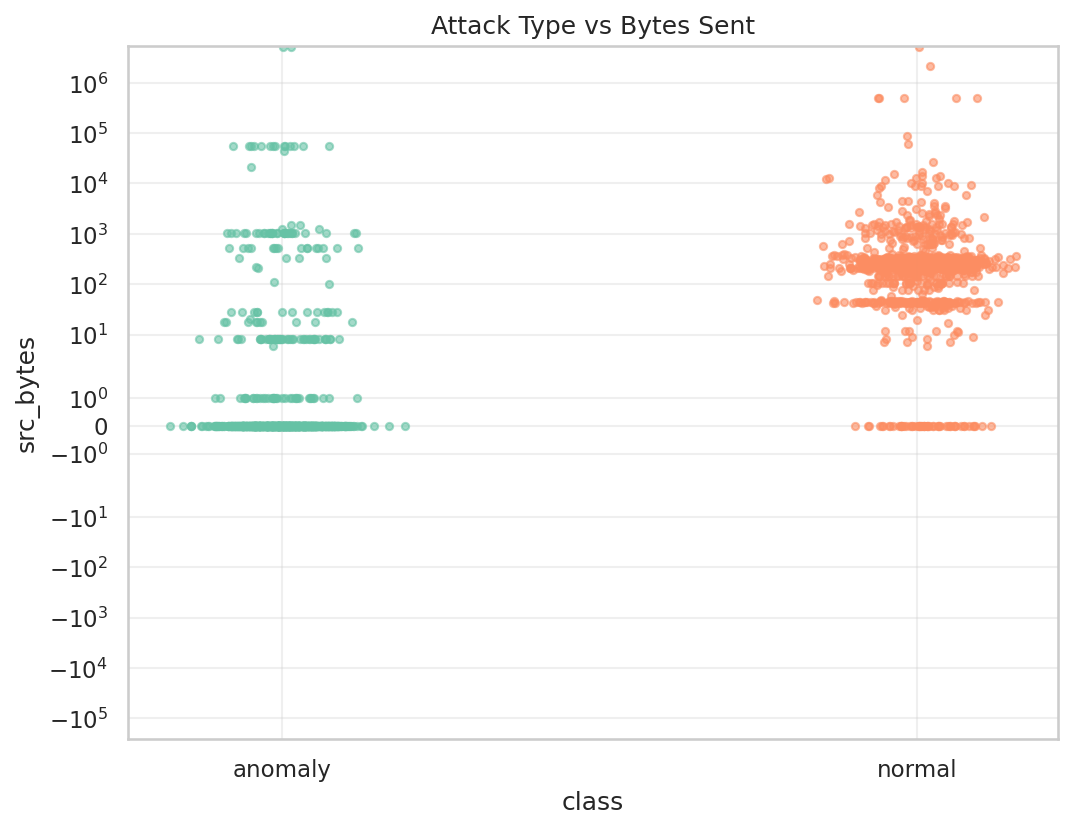

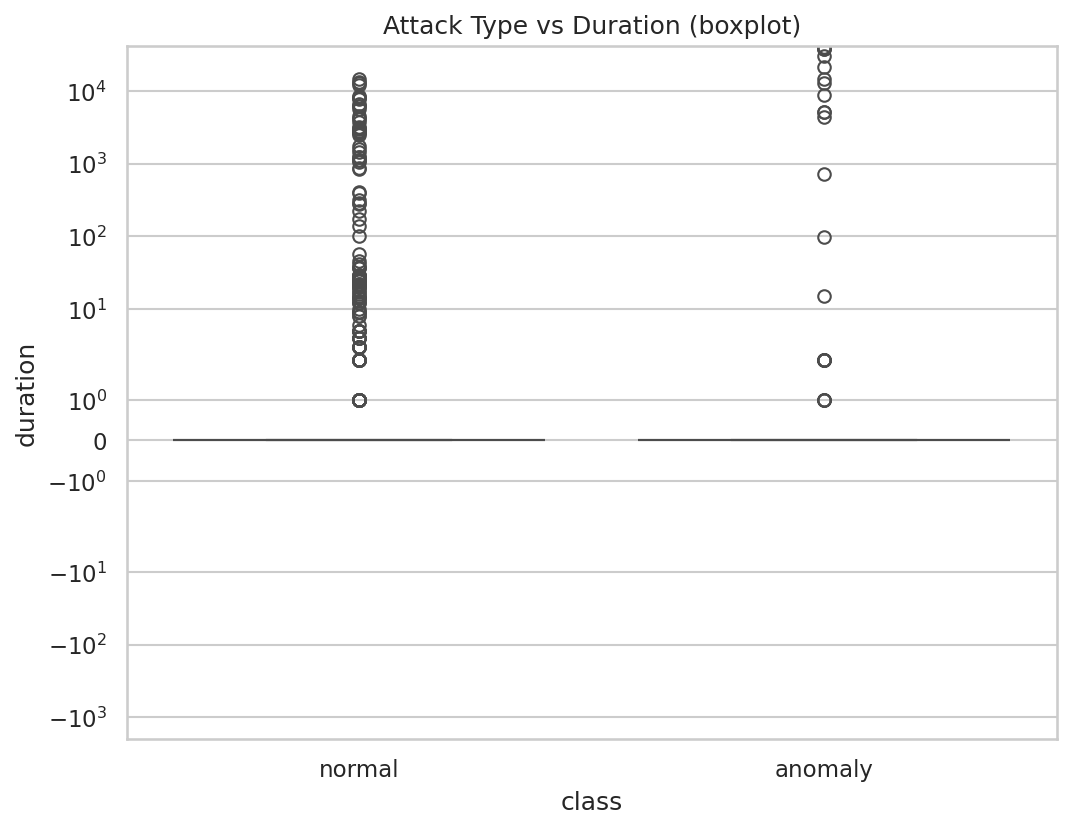

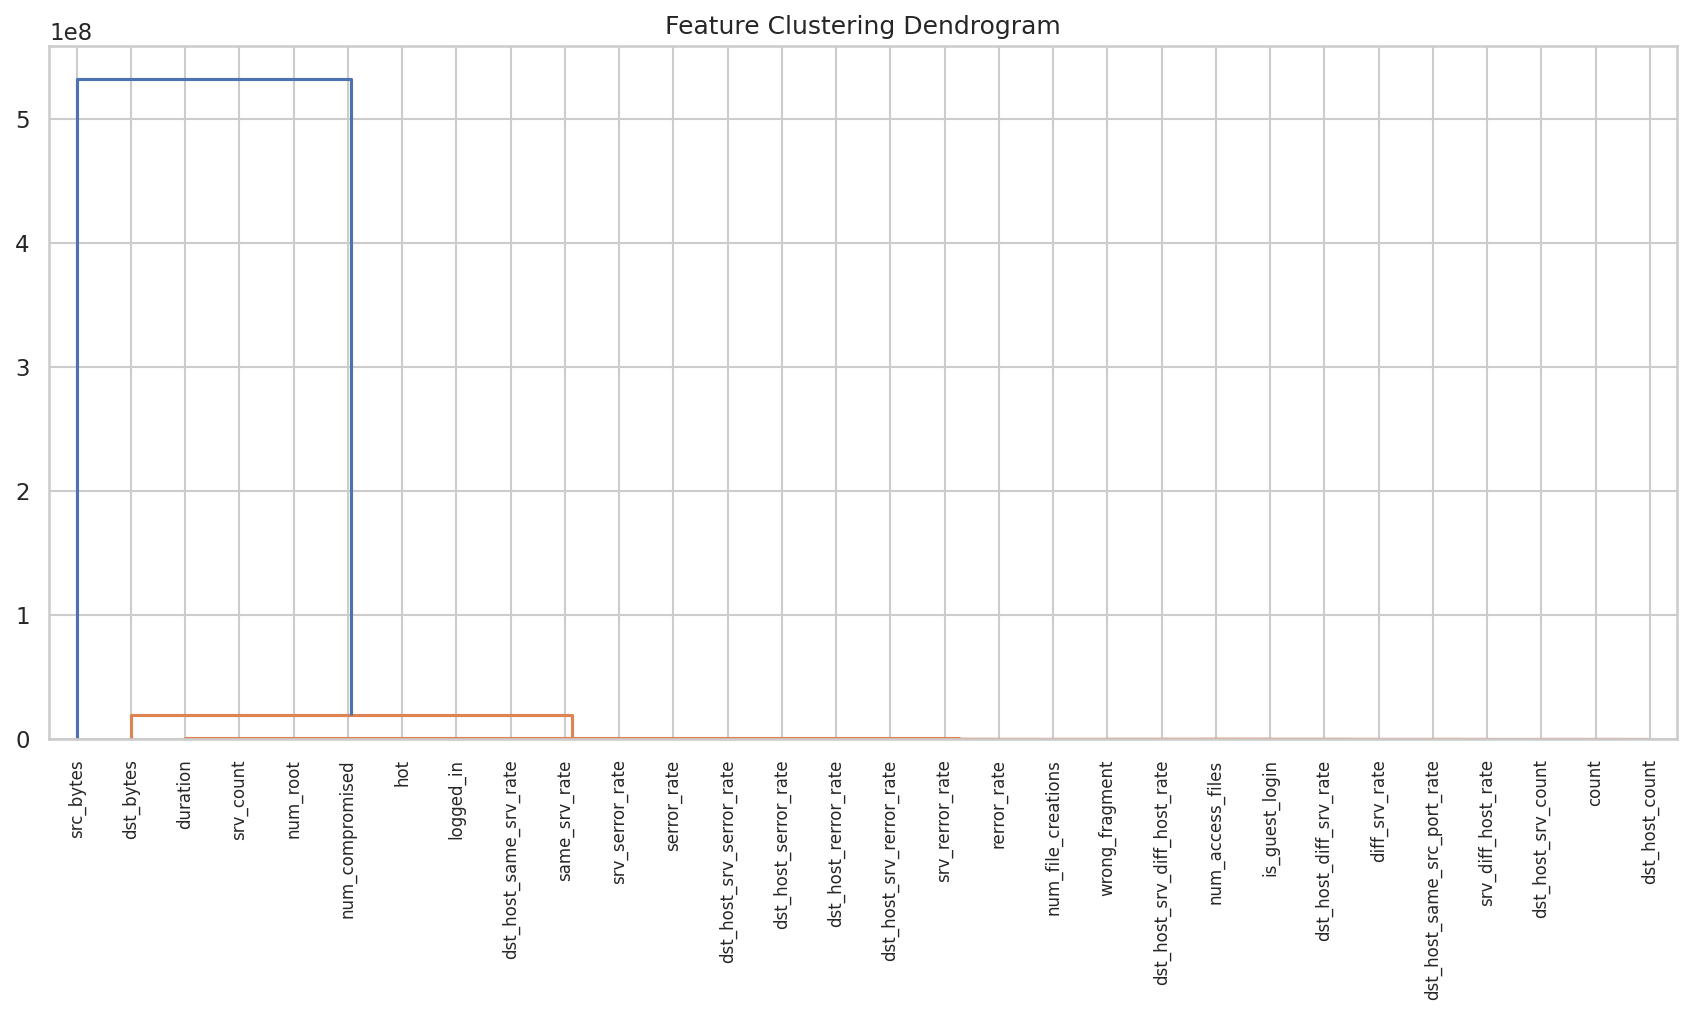


Final list of PNGs in output folder:
-  attack_type_distribution_bar.png
-  attack_vs_duration_boxplot.png
-  attack_vs_src_bytes.png
-  feature_clustering_dendrogram.png
-  feature_distributions_grid.png
-  feature_entropy.png
-  feature_importances_top15.png
-  label_distribution_donut.png
-  outlier_detection_feature_maxima.png
-  pca_visualization.png


In [ ]:
# Generating the three missing visualizations:
# - attack_vs_src_bytes.png
# - attack_vs_duration_boxplot.png
# - feature_clustering_dendrogram.png
# and then display them inline (if running in a notebook environment).

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram

OUTDIR = Path("/mnt/data/visualizations_output")
OUTDIR.mkdir(parents=True, exist_ok=True)
TRAIN_CSV = Path("/content/Train_data.csv")

df = pd.read_csv(TRAIN_CSV)
print("Loaded:", TRAIN_CSV, "shape:", df.shape)

# Helper to save fig
def save_fig(fig, name):
    path = OUTDIR / name
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print("Saved:", path)
    return str(path)

# 1) attack_vs_src_bytes.png (scatter of src_bytes by class)
if 'class' in df.columns and 'src_bytes' in df.columns:
    samp = df.sample(n=min(2000, len(df)), random_state=42)
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(1,1,1)
    # jitter x positions slightly for visualization
    classes = samp['class'].astype(str).values
    uniq = np.unique(classes)
    palette = sns.color_palette("Set2", n_colors=len(uniq))
    for i, c in enumerate(uniq):
        mask = classes == c
        x = np.random.normal(loc=float(i), scale=0.05, size=mask.sum())
        ax.scatter(x, samp.loc[mask, 'src_bytes'], s=12, alpha=0.6, label=str(c), color=palette[i])
    ax.set_xticks(list(range(len(uniq))))
    ax.set_xticklabels([str(u) for u in uniq])
    ax.set_xlabel("class")
    ax.set_ylabel("src_bytes")
    ax.set_title("Attack Type vs Bytes Sent")
    ax.set_yscale('symlog')  # show wide range better
    ax.grid(alpha=0.3)
    save_fig(fig, "attack_vs_src_bytes.png")
else:
    print("Skipping attack_vs_src_bytes: required columns missing ('class' and/or 'src_bytes').")

# 2) attack_vs_duration_boxplot.png (boxplot of duration by class)
if 'class' in df.columns and 'duration' in df.columns:
    samp = df.sample(n=min(2000, len(df)), random_state=24)
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(1,1,1)
    # seaborn boxplot; use log scale for y to handle extreme values
    try:
        sns.boxplot(x='class', y='duration', data=samp, showfliers=True, ax=ax)
        ax.set_yscale('symlog')
        ax.set_title("Attack Type vs Duration (boxplot)")
        ax.set_xlabel("class")
        ax.set_ylabel("duration")
        save_fig(fig, "attack_vs_duration_boxplot.png")
    except Exception as e:
        plt.close(fig)
        print("Boxplot failed:", e)
else:
    print("Skipping attack_vs_duration_boxplot: required columns missing ('class' and/or 'duration').")

# 3) feature_clustering_dendrogram.png (hierarchical clustering of top var features)
numeric = df.select_dtypes(include=[np.number]).copy()
if 'class' in numeric.columns:
    numeric = numeric.drop(columns=['class'])
vars_sorted = numeric.var().sort_values(ascending=False)
selected = vars_sorted.head(30).index.tolist() if len(vars_sorted) > 1 else vars_sorted.index.tolist()
if len(selected) > 1:
    # cluster features (transpose so features are rows)
    X = df[selected].fillna(0).T.values
    try:
        Z = linkage(X, method='ward')
        fig = plt.figure(figsize=(14,6))
        dendrogram(Z, labels=selected, leaf_rotation=90, leaf_font_size=8)
        plt.title("Feature Clustering Dendrogram")
        save_fig(fig, "feature_clustering_dendrogram.png")
    except Exception as e:
        print("Dendrogram generation failed:", e)
else:
    print("Skipping dendrogram: not enough numeric features.")

# Display the newly created files (if available)
from IPython.display import display, Image
for name in ["attack_vs_src_bytes.png", "attack_vs_duration_boxplot.png", "feature_clustering_dendrogram.png"]:
    p = OUTDIR / name
    if p.exists():
        display(Image(filename=str(p)))

# List all images now in folder
print("\nFinal list of PNGs in output folder:")
for p in sorted(OUTDIR.glob("*.png")):
    print("- ", p.name)
